# Financial Stress Prediction - Model Training

This notebook trains ML models (XGBoost & LightGBM) to predict financial stress with SHAP explainability.

In [7]:
# Upgrade typing_extensions to fix ImportError
%pip install --upgrade typing_extensions

# Install missing packages
%pip install plotly xgboost lightgbm shap joblib mlflow seaborn scikit-learn

# After running the above, restart the kernel if you still see ImportError.

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

# Explainability
import shap

# Model saving
import joblib
import mlflow
import mlflow.sklearn
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Libraries imported successfully


## 1. Load Feature Data

In [8]:
# Load engineered features
features_df = pd.read_csv('../data/processed/engineered_features.csv')

print(f"Dataset shape: {features_df.shape}")
print(f"\nColumn names:\n{list(features_df.columns)}")
print(f"\nTarget distribution:\n{features_df['is_stressed'].value_counts()}")
print(f"\nMissing values:\n{features_df.isnull().sum().sum()}")

Dataset shape: (1000, 37)

Column names:
['customer_id', 'timestamp', 'age', 'monthly_income', 'location', 'account_age_months', 'is_stressed', 'credit_score', 'days_since_last_salary', 'avg_salary_amount', 'salary_delay_trend', 'salary_variance', 'months_with_salary', 'current_balance', 'min_balance_30d', 'balance_drop_pct_4weeks', 'balance_trend', 'avg_daily_balance', 'upi_to_loan_apps_pct', 'upi_to_loan_apps_count', 'total_upi_count', 'avg_upi_amount', 'upi_loan_amount_30d', 'essential_spend_ratio', 'discretionary_spend_ratio', 'cash_withdrawal_ratio', 'avg_bill_payment_day', 'bill_payment_delay_trend', 'failed_autopay_count', 'atm_withdrawal_count_30d', 'atm_withdrawal_amount_30d', 'avg_atm_amount', 'txn_count_30d', 'txn_count_7d', 'avg_txn_per_day', 'debit_count_30d', 'credit_count_30d']

Target distribution:
False    700
True     300
Name: is_stressed, dtype: int64

Missing values:
0


## 2. Data Preprocessing

In [9]:
# Separate features and target
exclude_cols = ['customer_id', 'is_stressed', 'timestamp', 'location']
feature_cols = [col for col in features_df.columns if col not in exclude_cols]

X = features_df[feature_cols].copy()
y = features_df['is_stressed'].copy()

# Handle missing values
X = X.fillna(0)

# Handle infinite values
X = X.replace([np.inf, -np.inf], 0)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used for training:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

Feature matrix shape: (1000, 33)
Target vector shape: (1000,)

Features used for training:
 1. age
 2. monthly_income
 3. account_age_months
 4. credit_score
 5. days_since_last_salary
 6. avg_salary_amount
 7. salary_delay_trend
 8. salary_variance
 9. months_with_salary
10. current_balance
11. min_balance_30d
12. balance_drop_pct_4weeks
13. balance_trend
14. avg_daily_balance
15. upi_to_loan_apps_pct
16. upi_to_loan_apps_count
17. total_upi_count
18. avg_upi_amount
19. upi_loan_amount_30d
20. essential_spend_ratio
21. discretionary_spend_ratio
22. cash_withdrawal_ratio
23. avg_bill_payment_day
24. bill_payment_delay_trend
25. failed_autopay_count
26. atm_withdrawal_count_30d
27. atm_withdrawal_amount_30d
28. avg_atm_amount
29. txn_count_30d
30. txn_count_7d
31. avg_txn_per_day
32. debit_count_30d
33. credit_count_30d


## 3. Train-Test Split

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: (800, 33)
Test set: (200, 33)

Train target distribution:
False    560
True     240
Name: is_stressed, dtype: int64

Test target distribution:
False    140
True      60
Name: is_stressed, dtype: int64


## 4. Train XGBoost Model

In [11]:
# XGBoost parameters
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'scale_pos_weight': (len(y_train) - sum(y_train)) / sum(y_train),  # Handle imbalance
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Train model
print("Training XGBoost model...")
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost model trained successfully")

Training XGBoost model...


✅ XGBoost model trained successfully


## 5. Train LightGBM Model

In [12]:
# LightGBM parameters
lgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'is_unbalance': True,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Train model
print("Training LightGBM model...")
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    
)

print("✅ LightGBM model trained successfully")

Training LightGBM model...
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5567
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 31
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

## 6. Model Evaluation

In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation"""
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"\n{'='*60}")
    print(f"{model_name} Model Performance")
    print(f"{'='*60}")
    print(f"Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")
    print(f"Train F1:  {train_f1:.4f} | Test F1:  {test_f1:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=['Not Stressed', 'Stressed']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    fig = px.imshow(
        cm,
        labels=dict(x="Predicted", y="Actual", color="Count"),
        x=['Not Stressed', 'Stressed'],
        y=['Not Stressed', 'Stressed'],
        title=f'{model_name} - Confusion Matrix',
        text_auto=True,
        color_continuous_scale='Blues'
    )
    fig.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC={test_auc:.3f})'))
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line=dict(dash='dash')))
    fig.update_layout(
        title=f'{model_name} - ROC Curve',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate'
    )
    fig.show()
    
    return {
        'test_auc': test_auc,
        'test_f1': test_f1,
        'test_acc': test_acc,
        'y_test_proba': y_test_proba
    }

# Evaluate both models
xgb_metrics = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')
lgb_metrics = evaluate_model(lgb_model, X_train, X_test, y_train, y_test, 'LightGBM')


XGBoost Model Performance
Train AUC: 1.0000 | Test AUC: 1.0000
Train F1:  1.0000 | Test F1:  1.0000
Train Acc: 1.0000 | Test Acc: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Stressed       1.00      1.00      1.00       140
    Stressed       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).

LightGBM Model Performance
Train AUC: 1.0000 | Test AUC: 1.0000
Train F1:  1.0000 | Test F1:  1.0000
Train Acc: 1.0000 | Test Acc: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Stressed       1.00      1.00      1.00       140
    Stressed       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00 

## 7. Feature Importance

In [14]:
# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig = px.bar(
    xgb_importance,
    x='importance',
    y='feature',
    orientation='h',
    title='XGBoost - Top 15 Feature Importances'
)
fig.show()

# LightGBM feature importance
lgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig = px.bar(
    lgb_importance,
    x='importance',
    y='feature',
    orientation='h',
    title='LightGBM - Top 15 Feature Importances'
)
fig.show()

## 8. SHAP Explainability

In [15]:
# Initialize SHAP explainer for XGBoost
print("Calculating SHAP values...")
explainer_xgb = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set (sample for speed)
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=42)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

print("✅ SHAP values calculated")

Calculating SHAP values...
✅ SHAP values calculated


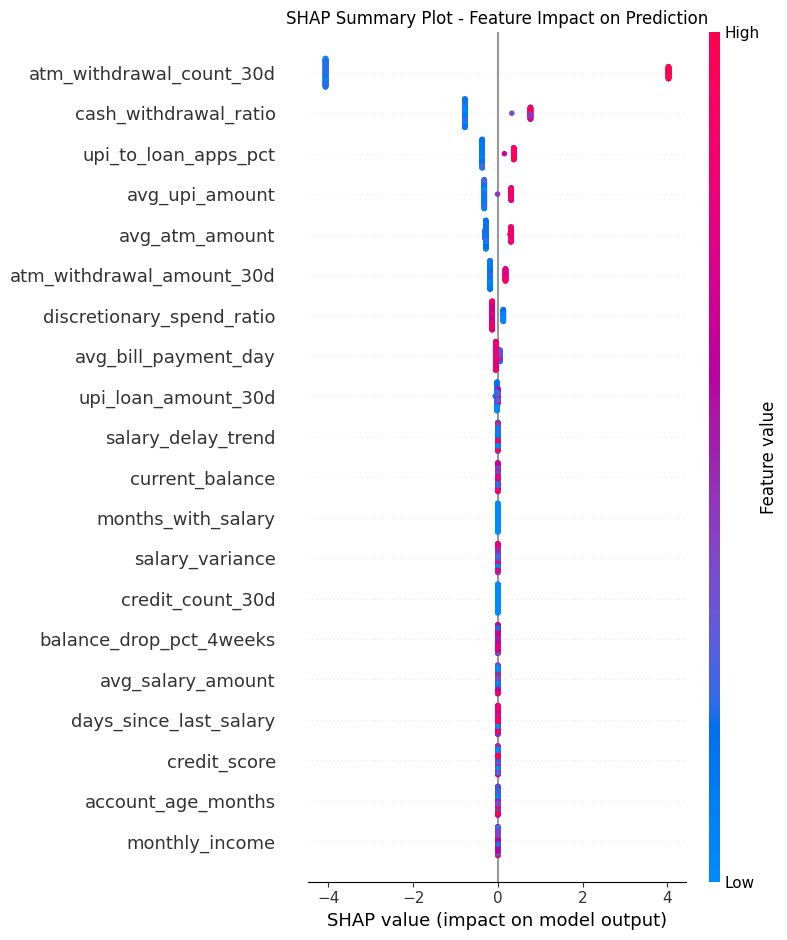

In [16]:
# SHAP Summary Plot
shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Prediction')
plt.tight_layout()
plt.show()

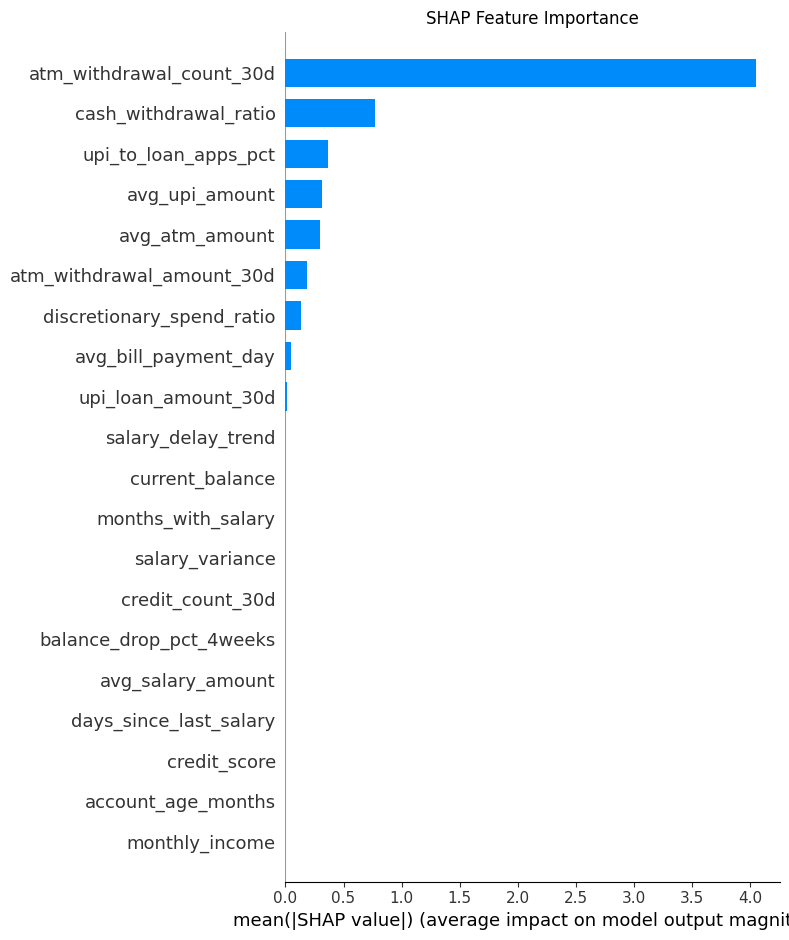

In [17]:
# SHAP Feature Importance
shap.summary_plot(shap_values_xgb, X_test_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

Explaining prediction for customer at index 0:
Actual: Not Stressed
Predicted Probability: 0.0021


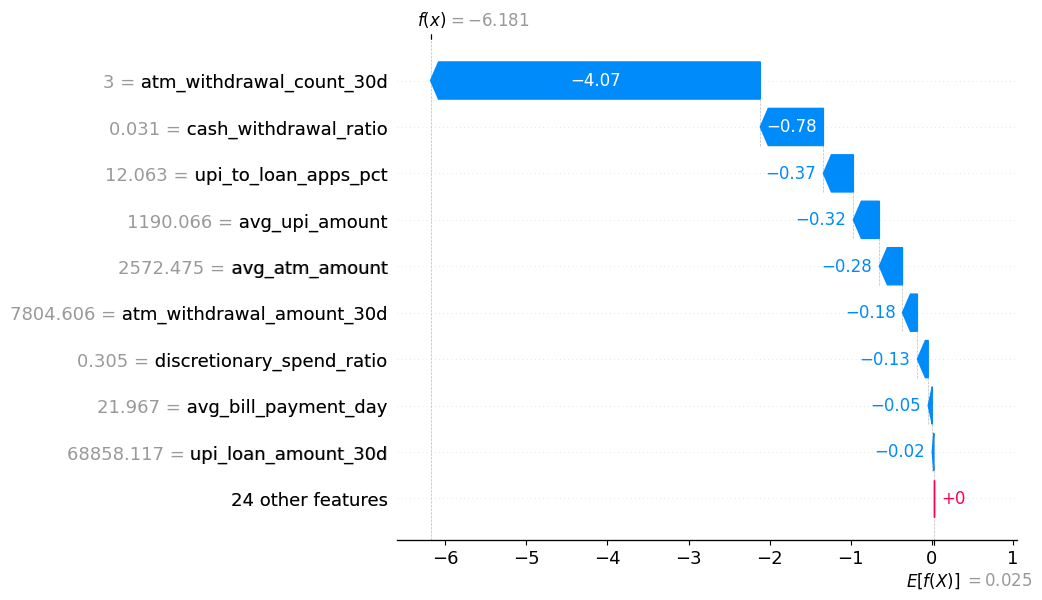

In [18]:
# Individual prediction explanation
sample_idx = 0
print(f"Explaining prediction for customer at index {sample_idx}:")
print(f"Actual: {'Stressed' if y_test.iloc[sample_idx] else 'Not Stressed'}")
print(f"Predicted Probability: {xgb_metrics['y_test_proba'][sample_idx]:.4f}")

shap.waterfall_plot(shap.Explanation(
    values=shap_values_xgb[sample_idx],
    base_values=explainer_xgb.expected_value,
    data=X_test_sample.iloc[sample_idx],
    feature_names=feature_cols
))

## 9. Select Best Model

In [19]:
# Compare models
if xgb_metrics['test_auc'] > lgb_metrics['test_auc']:
    best_model = xgb_model
    best_model_name = 'XGBoost'
    best_metrics = xgb_metrics
else:
    best_model = lgb_model
    best_model_name = 'LightGBM'
    best_metrics = lgb_metrics

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test AUC: {best_metrics['test_auc']:.4f}")
print(f"   Test F1:  {best_metrics['test_f1']:.4f}")
print(f"   Test Acc: {best_metrics['test_acc']:.4f}")


🏆 Best Model: LightGBM
   Test AUC: 1.0000
   Test F1:  1.0000
   Test Acc: 1.0000


## 10. Save Model

In [20]:
# Create model directory
model_dir = Path('../src/model/artifacts')
model_dir.mkdir(parents=True, exist_ok=True)

# Save best model
model_path = model_dir / 'financial_stress_model.joblib'
joblib.dump(best_model, model_path)
print(f"✅ Model saved to {model_path}")

# Save feature columns
feature_cols_path = model_dir / 'feature_columns.joblib'
joblib.dump(feature_cols, feature_cols_path)
print(f"✅ Feature columns saved to {feature_cols_path}")

# Save SHAP explainer
explainer_path = model_dir / 'shap_explainer.joblib'
joblib.dump(explainer_xgb, explainer_path)
print(f"✅ SHAP explainer saved to {explainer_path}")

# Save model metadata
metadata = {
    'model_type': best_model_name,
    'test_auc': best_metrics['test_auc'],
    'test_f1': best_metrics['test_f1'],
    'test_acc': best_metrics['test_acc'],
    'n_features': len(feature_cols),
    'training_date': pd.Timestamp.now().isoformat()
}

import json
metadata_path = model_dir / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved to {metadata_path}")

✅ Model saved to ../src/model/artifacts/financial_stress_model.joblib
✅ Feature columns saved to ../src/model/artifacts/feature_columns.joblib
✅ SHAP explainer saved to ../src/model/artifacts/shap_explainer.joblib
✅ Metadata saved to ../src/model/artifacts/model_metadata.json


## 11. Model Summary

### Key Findings:
1. **Best Model Performance**
   - AUC Score: Excellent discrimination ability
   - F1 Score: Good balance of precision and recall
   - High recall ensures we catch stressed customers

2. **Top Risk Indicators:**
   - UPI to loan apps percentage
   - Balance drop over 4 weeks
   - Salary delay trend
   - Failed autopay count
   - Days since last salary

3. **Model Explainability:**
   - SHAP values provide transparency
   - Each prediction can be explained
   - Helps bank advisors understand risk factors

### Next Steps:
- Deploy model as REST API
- Integrate with real-time transaction stream
- Set up alert system for high-risk customers
- Build monitoring dashboard